
# Assignment 03 — Customer Behavior / Interest Prediction
## Women's E-Commerce Clothing Reviews
### 3 Traditional ML Models vs. 5-Layer Deep Neural Network

## Problem Definition

Ta sử dụng `Review Text` để dự đoán:

\[
y = \text{Recommended IND} \in \{0,1\}
\]

- `0` = Not Recommended
- `1` = Recommended / Positive Interest

`Recommended IND` được dùng như một operational proxy cho user interest / recommendation intention.

### Traditional ML
1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

### Deep Learning
\[
d \rightarrow 256 \rightarrow 128 \rightarrow 64 \rightarrow 32 \rightarrow 1
\]

Trong đó \(d\) là số chiều TF-IDF.

### Metrics
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion Matrix
- Training Time

### Main Assignment 03 idea

Traditional ML:
```text
Review Text → Prepared Representation (TF-IDF) → ML Algorithm → Prediction
```

Deep Learning:
```text
Review Text → TF-IDF → H1 → H2 → H3 → H4 → Prediction
```

Các hidden vectors \(H_1,...,H_4\) là learned representations.



# 0. Environment Setup

Nếu PyTorch chưa được cài:

```python
%pip install torch
```

Sau đó Restart Kernel và chạy notebook lại từ đầu.


In [42]:
# %pip install torch

# 1. Import Libraries

In [43]:

import os
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# 2. Reproducibility

In [44]:

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

TARGET = "Recommended IND"
TEXT_COLUMN = "Review Text"

print("PyTorch version:", torch.__version__)


PyTorch version: 2.14.0+cpu



# 3. Load Dataset

Notebook thử một số tên file thường gặp. Nếu tên file khác, sửa `candidate_paths`.


In [45]:

candidate_paths = [
    "E-Commerce_Reviews.csv"
]

DATA_PATH = next(
    (p for p in candidate_paths if os.path.exists(p)),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy dataset. Hãy đặt CSV cùng thư mục notebook "
        "hoặc sửa candidate_paths."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset path :", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset path : E-Commerce_Reviews.csv
Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


# 4. Dataset Inspection

In [46]:

print("Columns:")
print(df.columns.tolist())

print("\nShape:", df.shape)

print("\nInfo:")
df.info()

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True)
})

display(quality_summary.round(2))
print("Duplicated rows:", df.duplicated().sum())


Columns:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Shape: (23486, 11)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5

,dtype,missing_count,missing_pct,unique_values
Unnamed: 0,int64,0,0.00,23486
Clothing ID,int64,0,0.00,1206
Age,int64,0,0.00,77
Title,str,3810,16.22,13993
Review Text,str,845,3.60,22634
Rating,int64,0,0.00,5
Recommended IND,int64,0,0.00,2
Positive Feedback Count,int64,0,0.00,82
Division Name,str,14,0.06,3
Department Name,str,14,0.06,6


Duplicated rows: 0


In [47]:

required_columns = [TEXT_COLUMN, TARGET]
missing_required = [c for c in required_columns if c not in df.columns]

if missing_required:
    raise ValueError(
        f"Dataset thiếu cột bắt buộc: {missing_required}"
    )

print("Target distribution:")
print(df[TARGET].value_counts(dropna=False).sort_index())


Target distribution:
Recommended IND
0     4172
1    19314
Name: count, dtype: int64



# 5. Data Cleaning

Ta loại:

1. index-like column `Unnamed: ...` nếu có;
2. exact duplicate rows;
3. target không thuộc `{0,1}`;
4. review bị thiếu hoặc rỗng.

Ta không dùng `Rating` làm target vì supervised task đã được chốt:

```text
Review Text → Recommended IND
```


In [48]:

df_clean = df.copy()

unnamed_columns = [
    c for c in df_clean.columns
    if str(c).lower().startswith("unnamed:")
]

if unnamed_columns:
    df_clean = df_clean.drop(columns=unnamed_columns)

print("Removed index-like columns:", unnamed_columns)

before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Removed duplicates:", before - len(df_clean))

df_clean[TARGET] = pd.to_numeric(
    df_clean[TARGET],
    errors="coerce"
)

before = len(df_clean)
df_clean = df_clean[df_clean[TARGET].isin([0, 1])].copy()
df_clean[TARGET] = df_clean[TARGET].astype(int)
print("Removed invalid target rows:", before - len(df_clean))

before = len(df_clean)

df_clean = df_clean[df_clean[TEXT_COLUMN].notna()].copy()
df_clean[TEXT_COLUMN] = (
    df_clean[TEXT_COLUMN]
    .astype(str)
    .str.strip()
)

df_clean = df_clean[
    df_clean[TEXT_COLUMN].str.len() > 0
].copy()

df_clean.reset_index(drop=True, inplace=True)

print("Removed missing/empty reviews:", before - len(df_clean))
print("Final cleaned shape:", df_clean.shape)


Removed index-like columns: ['Unnamed: 0']
Removed duplicates: 21
Removed invalid target rows: 0
Removed missing/empty reviews: 825
Final cleaned shape: (22640, 10)


# 6. Define Input and Target

In [49]:

X_text = df_clean[TEXT_COLUMN].copy()
y = df_clean[TARGET].copy()

print("Number of reviews:", len(X_text))
print("Target shape:", y.shape)

print("\nExample review:")
print(X_text.iloc[0])

print("\nTarget:", y.iloc[0])


Number of reviews: 22640
Target shape: (22640,)

Example review:
Absolutely wonderful - silky and sexy and comfortable

Target: 1



# 7. Exploratory Data Analysis

Các hình chính:

- class distribution;
- review length;
- Rating distribution nếu có;
- Recommended rate theo Rating;
- sample reviews.


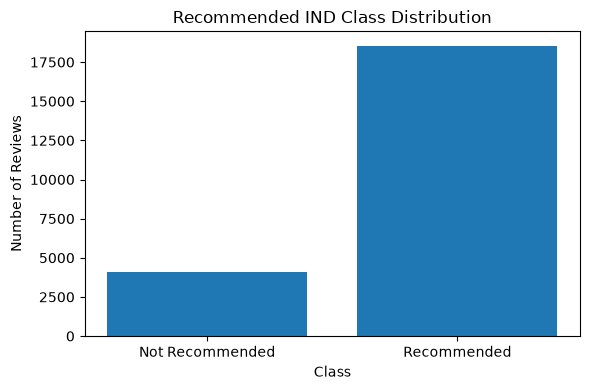

,Percentage
Recommended IND,
0,18.11
1,81.89


In [50]:

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Not Recommended", "Recommended"],
    class_counts.values
)
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.title("Recommended IND Class Distribution")
plt.tight_layout()
plt.show()

class_ratio = y.value_counts(normalize=True).sort_index() * 100
display(class_ratio.round(2).to_frame(name="Percentage"))


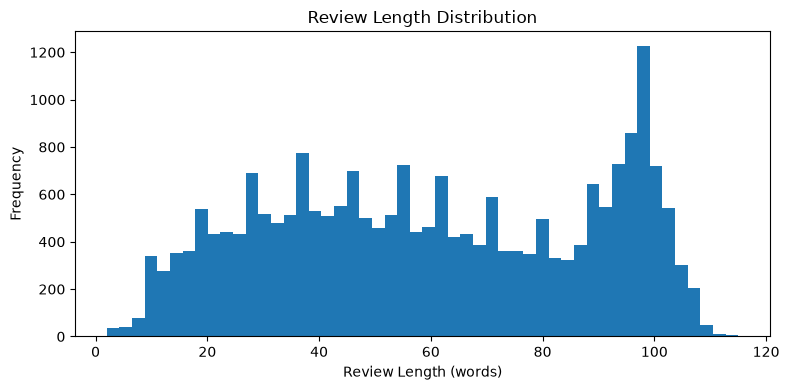

,Review Length
count,22640.000000
mean,60.197482
std,28.534986
min,2.000000
25%,36.000000
50%,59.000000
75%,88.000000
max,115.000000


In [51]:

review_length_words = X_text.str.split().str.len()

plt.figure(figsize=(8, 4))
plt.hist(review_length_words, bins=50)
plt.xlabel("Review Length (words)")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.tight_layout()
plt.show()

display(review_length_words.describe().to_frame(name="Review Length"))


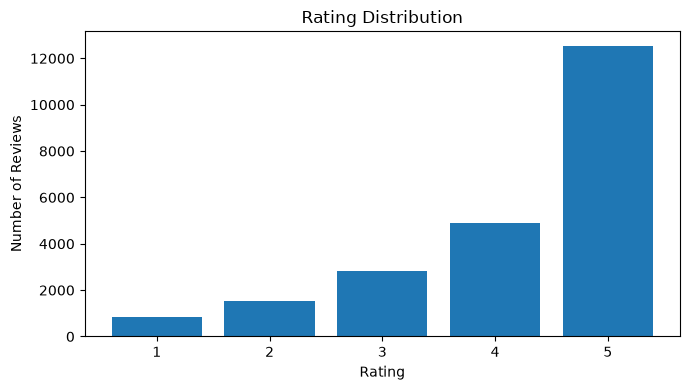

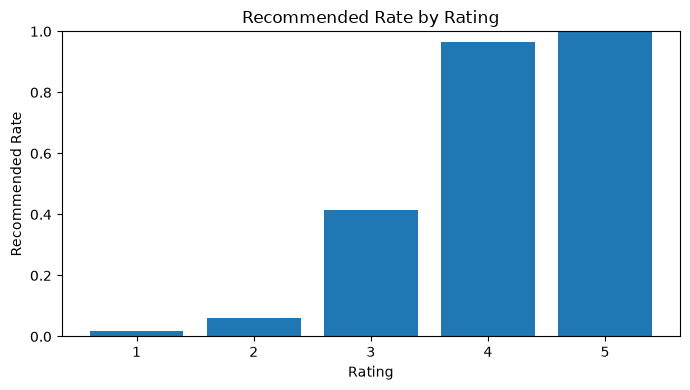

,Recommended Rate
Rating,
1,0.018270
2,0.060684
3,0.414453
4,0.966585
5,0.998166


In [52]:

if "Rating" in df_clean.columns:
    rating_counts = df_clean["Rating"].value_counts().sort_index()

    plt.figure(figsize=(7, 4))
    plt.bar(rating_counts.index.astype(str), rating_counts.values)
    plt.xlabel("Rating")
    plt.ylabel("Number of Reviews")
    plt.title("Rating Distribution")
    plt.tight_layout()
    plt.show()

    rating_interest = df_clean.groupby("Rating")[TARGET].mean()

    plt.figure(figsize=(7, 4))
    plt.bar(rating_interest.index.astype(str), rating_interest.values)
    plt.ylim(0, 1)
    plt.xlabel("Rating")
    plt.ylabel("Recommended Rate")
    plt.title("Recommended Rate by Rating")
    plt.tight_layout()
    plt.show()

    display(rating_interest.to_frame(name="Recommended Rate"))


In [53]:

print("Example NOT RECOMMENDED reviews:")
display(
    df_clean[df_clean[TARGET] == 0][[TEXT_COLUMN, TARGET]].head(3)
)

print("\nExample RECOMMENDED reviews:")
display(
    df_clean[df_clean[TARGET] == 1][[TEXT_COLUMN, TARGET]].head(3)
)


Example NOT RECOMMENDED reviews:


,Review Text,Recommended IND
2,I had such high hopes for this dress and reall...,0
5,"I love tracy reese dresses, but this one is no...",0
10,Dress runs small esp where the zipper area run...,0



Example RECOMMENDED reviews:


,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
3,"I love, love, love this jumpsuit. it's fun, fl...",1



# 8. Train / Validation / Test Split

- 70% Train
- 15% Validation
- 15% Test

Vì đây là classification, dùng `stratify=y`.

Test chỉ dùng cho final evaluation.


In [54]:

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

split_summary = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Rows": [len(X_train_text), len(X_val_text), len(X_test_text)],
    "Recommended %": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

display(split_summary.round(2))


,Set,Rows,Recommended %
0,Train,15848,81.88
1,Validation,3396,81.89
2,Test,3396,81.89



# 9. Text Representation — TF-IDF

Raw text phải được chuyển thành numerical representation.

\[
x = [x_1,x_2,\ldots,x_d]
\]

Một cách biểu diễn phổ biến:

\[
TFIDF(t,d)
=
TF(t,d)
\times
\log\frac{N}{DF(t)}
\]

Pipeline:

```text
Review Text
   ↓
Lowercase / Tokenization
   ↓
TF-IDF
   ↓
x ∈ R^d
   ↓
ML / DL
```

Vectorizer chỉ được `fit` trên Train để tránh data leakage.


In [55]:

MAX_FEATURES = 1500

def build_vectorizer():
    return TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        dtype=np.float32
    )

vectorizer = build_vectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)
X_test_tfidf = vectorizer.transform(X_test_text)

feature_names = vectorizer.get_feature_names_out()

print("Train TF-IDF shape     :", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape      :", X_test_tfidf.shape)
print("Vocabulary size        :", len(feature_names))


Train TF-IDF shape     : (15848, 1500)
Validation TF-IDF shape: (3396, 1500)
Test TF-IDF shape      : (3396, 1500)
Vocabulary size        : 1500


In [56]:

sample_text = X_train_text.iloc[0]
sample_vector = vectorizer.transform([sample_text])

nonzero_indices = sample_vector.nonzero()[1]

sample_features = pd.DataFrame({
    "Term": feature_names[nonzero_indices],
    "TF-IDF": sample_vector[0, nonzero_indices].toarray().ravel()
}).sort_values("TF-IDF", ascending=False)

print("Raw review:")
print(sample_text)

print("\nTop TF-IDF dimensions:")
display(sample_features.head(15))


Raw review:
I saw this online and wasnt sure and actually walked right past it in the store. but my usual stylist walked around the store with me and insisted it was a goodone. she usually knows what she is talking about... super soft nd comfortable, love the long sleeves (it has hidden buttons), cut is flattering on everyone. i ended up ordering petite size. turtleneck is not too tight, and the dress can pretty mjuch be dressed up or down. my friend also bought it (huhm twinsies)!! my favorite design was t

Top TF-IDF dimensions:


,Term,TF-IDF
4,comfortable love,0.242026
15,long sleeves,0.240006
9,dress pretty,0.235691
34,turtleneck,0.228835
6,cut flattering,0.227887
25,saw online,0.217061
19,past,0.213127
29,store,0.212927
21,petite size,0.209582
18,ordering,0.192794



# 10. Classification Metrics

Positive class:

\[
Recommended = 1
\]

## Accuracy

\[
Accuracy=
\frac{TP+TN}{TP+TN+FP+FN}
\]

## Precision

\[
Precision=
\frac{TP}{TP+FP}
\]

## Recall

\[
Recall=
\frac{TP}{TP+FN}
\]

## F1

\[
F1=
2\frac{Precision\times Recall}{Precision+Recall}
\]

## ROC-AUC

Đánh giá khả năng model phân biệt/xếp hạng hai class trên nhiều threshold.

Không nên chỉ nhìn Accuracy nếu target mất cân bằng.


In [57]:

def classification_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score)
    }

def get_model_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    raise ValueError("Model has no probability or decision score.")



# 11. Traditional Machine Learning — 3 Models

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM


In [58]:

ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(
        random_state=RANDOM_STATE
    )
}

ml_validation_results = []
trained_ml_models = {}

for name, model in ml_models.items():
    print(f"Training {name}...")

    start = time.perf_counter()

    model.fit(X_train_tfidf, y_train)

    training_time = time.perf_counter() - start

    val_pred = model.predict(X_val_tfidf)
    val_score = get_model_score(model, X_val_tfidf)

    metrics = classification_metrics(
        y_val,
        val_pred,
        val_score
    )

    ml_validation_results.append({
        "Model": name,
        **metrics,
        "Training Time (s)": training_time
    })

    trained_ml_models[name] = model

ml_validation_df = (
    pd.DataFrame(ml_validation_results)
    .sort_values(
        by=["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(ml_validation_df.round(4))


Training Logistic Regression...
Training Multinomial Naive Bayes...
Training Linear SVM...


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
0,Logistic Regression,0.8816,0.9006,0.9615,0.9301,0.9237,0.1898
1,Linear SVM,0.8763,0.9081,0.9446,0.9260,0.9119,0.1189
2,Multinomial Naive Bayes,0.8622,0.8663,0.9835,0.9212,0.9176,0.0094


# 12. ML Validation Visualization

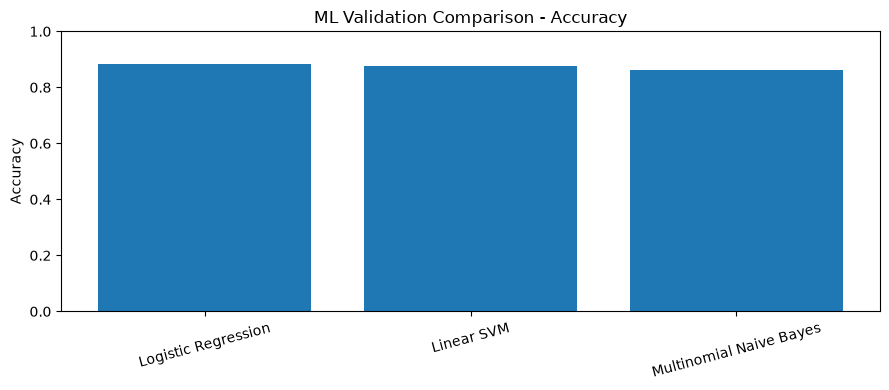

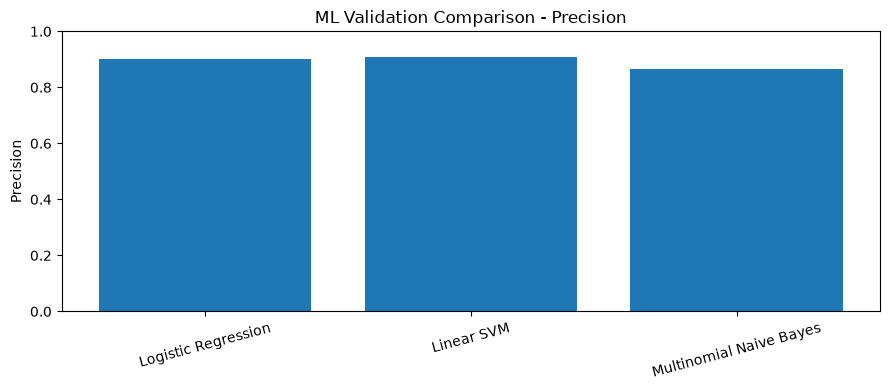

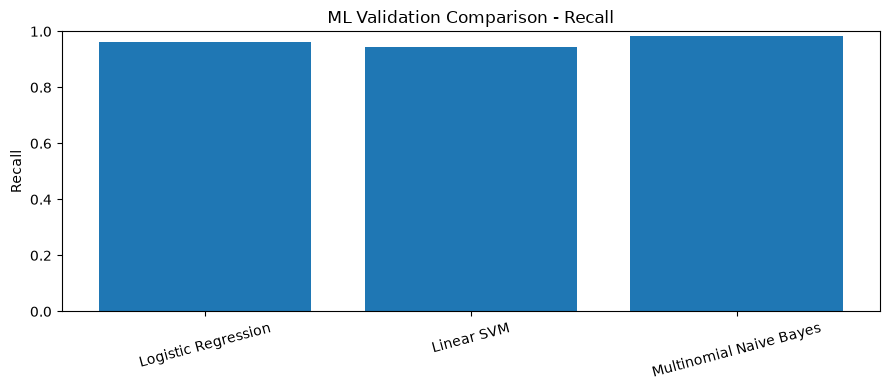

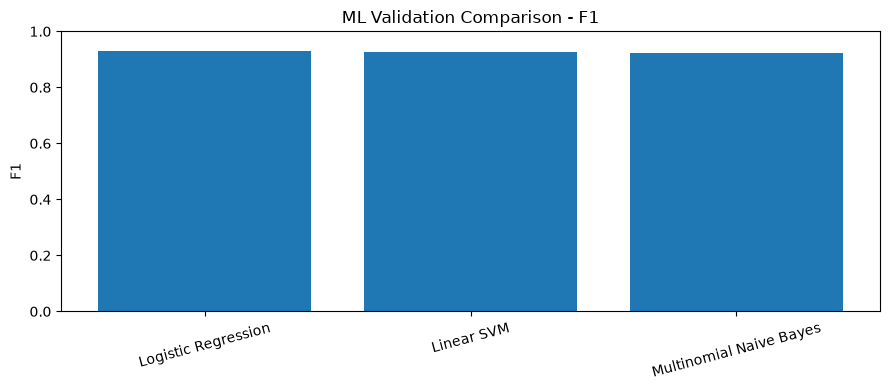

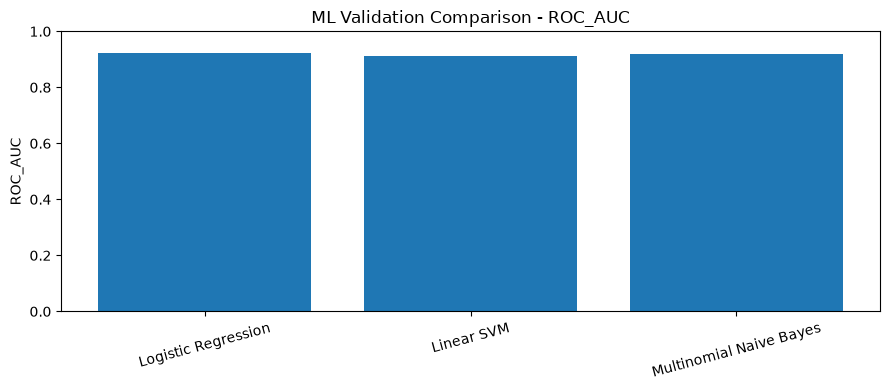

In [59]:

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]:
    plt.figure(figsize=(9, 4))
    plt.bar(
        ml_validation_df["Model"],
        ml_validation_df[metric]
    )
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"ML Validation Comparison - {metric}")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



# 13. Deep Learning Theory

Assignment 03 xem Neural Network như một composition of learned functions:

\[
x
\rightarrow
h_\theta(x)
\rightarrow
\hat y
\]

## A Neuron

\[
z=w^Tx+b
\]

\[
h=\phi(z)
\]

## Linear Layer

\[
z=Wx+b
\]

## ReLU

\[
ReLU(z)=\max(0,z)
\]

Depth + nonlinearity cho phép network học nonlinear representations.



# 14. 5-Layer MLP — Forward Propagation

Input:

\[
X\in\mathbb{R}^{N\times d}
\]

Architecture:

\[
d
\rightarrow
256
\rightarrow
128
\rightarrow
64
\rightarrow
32
\rightarrow
1
\]

## Layer 1

\[
Z_1=XW_1+b_1
\]

\[
H_1=ReLU(Z_1)
\]

## Layer 2

\[
Z_2=H_1W_2+b_2
\]

\[
H_2=ReLU(Z_2)
\]

## Layer 3

\[
Z_3=H_2W_3+b_3
\]

\[
H_3=ReLU(Z_3)
\]

## Layer 4

\[
Z_4=H_3W_4+b_4
\]

\[
H_4=ReLU(Z_4)
\]

## Layer 5

\[
Z_5=H_4W_5+b_5
\]

Prediction probability:

\[
\hat y=\sigma(Z_5)
=
\frac{1}{1+e^{-Z_5}}
\]

Complete flow:

\[
X
\rightarrow H_1
\rightarrow H_2
\rightarrow H_3
\rightarrow H_4
\rightarrow \hat y
\]

\(H_1,...,H_4\) là learned representations.



# 15. Binary Cross-Entropy Loss

\[
L=
-\frac{1}{N}
\sum_{i=1}^{N}
[
y_i\log(\hat y_i)
+
(1-y_i)\log(1-\hat y_i)
]
\]

Trong PyTorch:

```python
criterion = nn.BCEWithLogitsLoss()
```

Model trả về **logit** \(Z_5\), không đặt Sigmoid trực tiếp trong output khi training.



# 16. Backpropagation + Gradient Descent

Training cycle:

```text
Input Batch
   ↓
Forward
   ↓
Loss
   ↓
Backward
   ↓
Optimizer Step
```

Backpropagation tính:

\[
\nabla_\theta L
\]

Gradient descent:

\[
\theta_{t+1}
=
\theta_t-\eta\nabla_\theta L
\]

Trong PyTorch:

```python
optimizer.zero_grad()
logits = model(X_batch)
loss = criterion(logits, y_batch)
loss.backward()
optimizer.step()
```



# 17. TF-IDF → Tensor → DataLoader

Traditional ML dùng sparse TF-IDF.

5-Layer MLP dùng dense `float32` tensor.

`MAX_FEATURES=1500` giúp notebook chạy thực tế trên laptop.


In [60]:

X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_val_dense = X_val_tfidf.toarray().astype(np.float32)
X_test_dense = X_test_tfidf.toarray().astype(np.float32)

X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(X_val_dense, dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32)
y_test_tensor = torch.tensor(
    y_test.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)


X_train_tensor: torch.Size([15848, 1500])
y_train_tensor: torch.Size([15848, 1])


In [61]:

BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

X_batch, y_batch = next(iter(train_loader))

print("One X batch:", X_batch.shape)
print("One y batch:", y_batch.shape)


One X batch: torch.Size([128, 1500])
One y batch: torch.Size([128, 1])



# 18. Tensor Shapes

Với batch size \(B\):

\[
B\times d
\rightarrow
B\times256
\rightarrow
B\times128
\rightarrow
B\times64
\rightarrow
B\times32
\rightarrow
B\times1
\]


In [62]:

class CustomerInterestMLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 256)  # Layer 1
        self.fc2 = nn.Linear(256, 128)        # Layer 2
        self.fc3 = nn.Linear(128, 64)         # Layer 3
        self.fc4 = nn.Linear(64, 32)          # Layer 4
        self.fc5 = nn.Linear(32, 1)           # Layer 5

        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))

        # Return logit
        z5 = self.fc5(h4)

        return z5


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

INPUT_DIM = X_train_dense.shape[1]

dl_model = CustomerInterestMLP(
    INPUT_DIM
).to(device)

print("Device   :", device)
print("Input dim:", INPUT_DIM)
print(dl_model)


Device   : cpu
Input dim: 1500
CustomerInterestMLP(
  (fc1): Linear(in_features=1500, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (fc5): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)



# 19. Number of Trainable Parameters

Với Linear layer:

\[
parameters
=
d_{in}\times d_{out}
+
d_{out}
\]

Phần cuối là bias.


In [63]:

total_params = sum(
    p.numel()
    for p in dl_model.parameters()
    if p.requires_grad
)

print("Total trainable parameters:", total_params)

for name, parameter in dl_model.named_parameters():
    print(
        f"{name:12s} | "
        f"shape={tuple(parameter.shape)} | "
        f"params={parameter.numel()}"
    )


Total trainable parameters: 427521
fc1.weight   | shape=(256, 1500) | params=384000
fc1.bias     | shape=(256,) | params=256
fc2.weight   | shape=(128, 256) | params=32768
fc2.bias     | shape=(128,) | params=128
fc3.weight   | shape=(64, 128) | params=8192
fc3.bias     | shape=(64,) | params=64
fc4.weight   | shape=(32, 64) | params=2048
fc4.bias     | shape=(32,) | params=32
fc5.weight   | shape=(1, 32) | params=32
fc5.bias     | shape=(1,) | params=1


# 20. Loss + Optimizer

In [64]:

LEARNING_RATE = 0.001
NUM_EPOCHS = 80
PATIENCE = 12

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    dl_model.parameters(),
    lr=LEARNING_RATE
)

print("Loss         :", criterion)
print("Optimizer    :", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Epochs       :", NUM_EPOCHS)
print("Batch size   :", BATCH_SIZE)
print("Patience     :", PATIENCE)


Loss         : BCEWithLogitsLoss()
Optimizer    : Adam
Learning rate: 0.001
Epochs       : 80
Batch size   : 128
Patience     : 12



# 21. DL Evaluation Function

Validation/Test:

```python
model.eval()

with torch.no_grad():
    logits = model(X)
    probability = torch.sigmoid(logits)
```


In [65]:

def evaluate_dl_classifier(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    probabilities_all = []
    predictions_all = []
    targets_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).int()

            probabilities_all.extend(
                probabilities.cpu().numpy().ravel()
            )
            predictions_all.extend(
                predictions.cpu().numpy().ravel()
            )
            targets_all.extend(
                y_batch.cpu().numpy().ravel()
            )

    probabilities_all = np.array(probabilities_all)
    predictions_all = np.array(predictions_all).astype(int)
    targets_all = np.array(targets_all).astype(int)

    metrics = classification_metrics(
        targets_all,
        predictions_all,
        probabilities_all
    )

    return {
        "loss": total_loss / len(loader.dataset),
        "probabilities": probabilities_all,
        "predictions": predictions_all,
        "targets": targets_all,
        **metrics
    }



# 22. Training Loop

Theo dõi:

- Training Loss
- Validation Loss
- Training Accuracy
- Validation Accuracy
- Training F1
- Validation F1

Best model được chọn theo validation loss.


In [66]:

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

train_f1_history = []
val_f1_history = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = None

epochs_without_improvement = 0

dl_start = time.perf_counter()

for epoch in range(NUM_EPOCHS):

    dl_model.train()

    running_loss = 0.0

    train_probabilities = []
    train_predictions = []
    train_targets = []

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = dl_model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).int()

        train_probabilities.extend(
            probabilities.detach().cpu().numpy().ravel()
        )
        train_predictions.extend(
            predictions.detach().cpu().numpy().ravel()
        )
        train_targets.extend(
            y_batch.detach().cpu().numpy().ravel()
        )

    train_loss = running_loss / len(train_loader.dataset)

    train_metrics = classification_metrics(
        np.array(train_targets).astype(int),
        np.array(train_predictions).astype(int),
        np.array(train_probabilities)
    )

    val_result = evaluate_dl_classifier(
        dl_model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_result["loss"])

    train_accuracies.append(train_metrics["Accuracy"])
    val_accuracies.append(val_result["Accuracy"])

    train_f1_history.append(train_metrics["F1"])
    val_f1_history.append(val_result["F1"])

    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(
            dl_model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_result['loss']:.4f} | "
            f"Train Acc: {train_metrics['Accuracy']:.4f} | "
            f"Val Acc: {val_result['Accuracy']:.4f} | "
            f"Val F1: {val_result['F1']:.4f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print("\nEarly stopping at epoch", epoch + 1)
        break

dl_training_time = time.perf_counter() - dl_start

dl_model.load_state_dict(
    best_model_state
)

print("\nTraining completed.")
print("Best epoch       :", best_epoch)
print("Best val loss    :", round(best_val_loss, 4))
print("DL training time :", round(dl_training_time, 4), "seconds")


Epoch   1/80 | Train Loss: 0.3980 | Val Loss: 0.2795 | Train Acc: 0.8239 | Val Acc: 0.8831 | Val F1: 0.9301
Epoch   5/80 | Train Loss: 0.1087 | Val Loss: 0.3811 | Train Acc: 0.9626 | Val Acc: 0.8713 | Val F1: 0.9207
Epoch  10/80 | Train Loss: 0.0017 | Val Loss: 0.9493 | Train Acc: 0.9999 | Val Acc: 0.8663 | Val F1: 0.9183

Early stopping at epoch 14

Training completed.
Best epoch       : 2
Best val loss    : 0.2643
DL training time : 22.6742 seconds



# 23. Training / Validation Curves

- Train và Validation cùng tốt lên → good fit
- Train tốt lên nhưng Validation xấu đi → overfitting
- Cả hai đều kém → underfitting

High training accuracy không đồng nghĩa với good generalization.


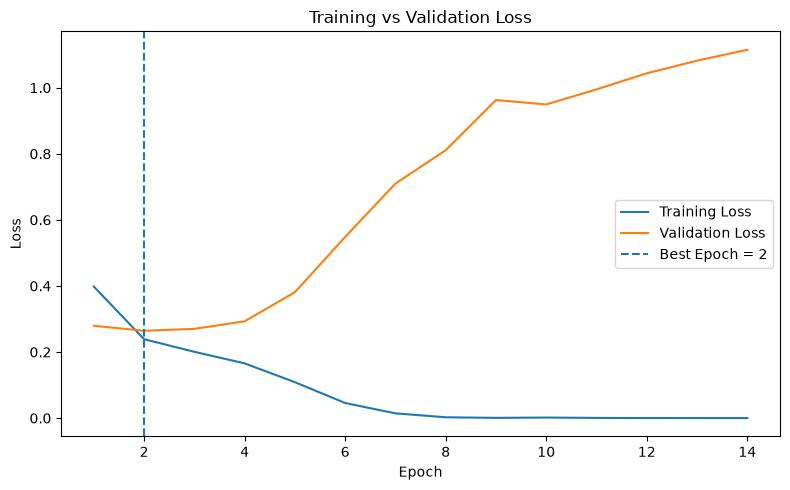

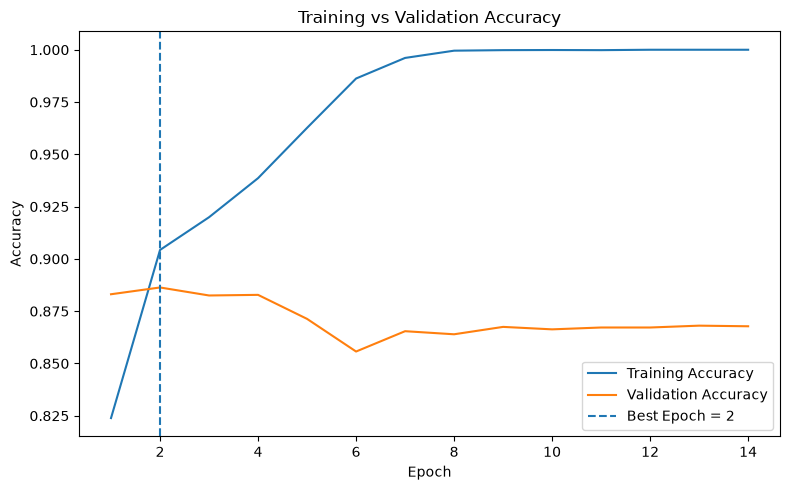

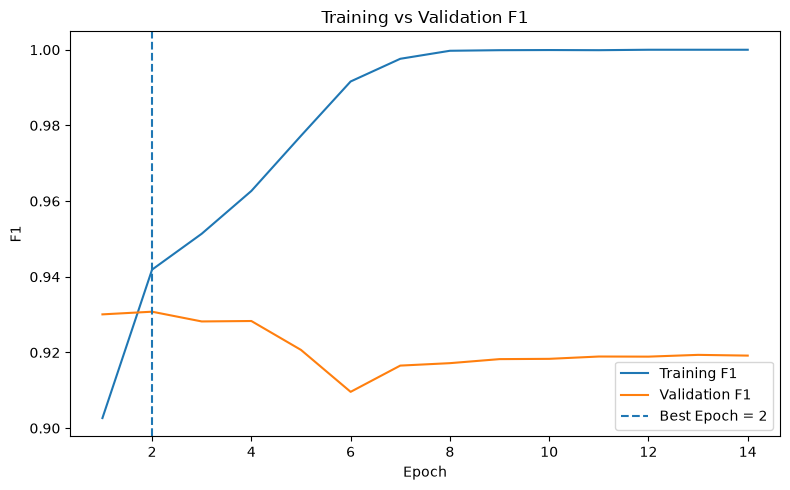

In [67]:

epochs_ran = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, train_losses, label="Training Loss")
plt.plot(epochs_ran, val_losses, label="Validation Loss")
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, train_accuracies, label="Training Accuracy")
plt.plot(epochs_ran, val_accuracies, label="Validation Accuracy")
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, train_f1_history, label="Training F1")
plt.plot(epochs_ran, val_f1_history, label="Validation F1")
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
plt.tight_layout()
plt.show()


# 24. Validation Comparison — 3 ML + DL

In [68]:

dl_val_result = evaluate_dl_classifier(
    dl_model,
    val_loader,
    criterion,
    device
)

dl_validation_row = {
    "Model": "5-Layer MLP",
    "Accuracy": dl_val_result["Accuracy"],
    "Precision": dl_val_result["Precision"],
    "Recall": dl_val_result["Recall"],
    "F1": dl_val_result["F1"],
    "ROC_AUC": dl_val_result["ROC_AUC"],
    "Training Time (s)": dl_training_time
}

validation_comparison = pd.concat(
    [
        ml_validation_df,
        pd.DataFrame([dl_validation_row])
    ],
    ignore_index=True
)

validation_comparison = (
    validation_comparison
    .sort_values(
        by=["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(validation_comparison.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
0,5-Layer MLP,0.8863,0.9284,0.9331,0.9308,0.9226,22.6742
1,Logistic Regression,0.8816,0.9006,0.9615,0.9301,0.9237,0.1898
2,Linear SVM,0.8763,0.9081,0.9446,0.9260,0.9119,0.1189
3,Multinomial Naive Bayes,0.8622,0.8663,0.9835,0.9212,0.9176,0.0094


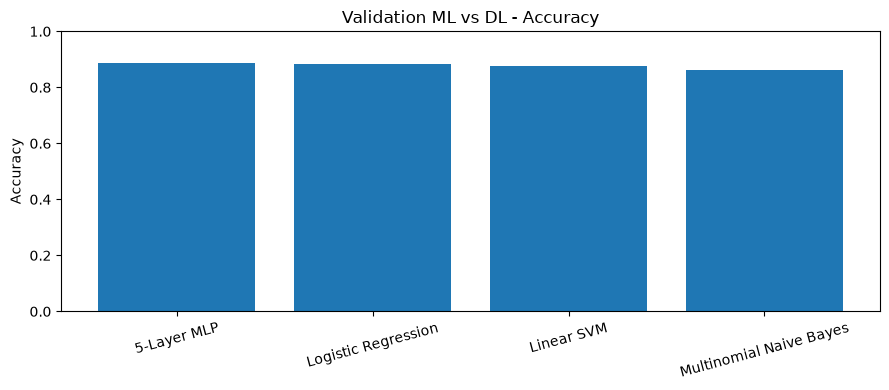

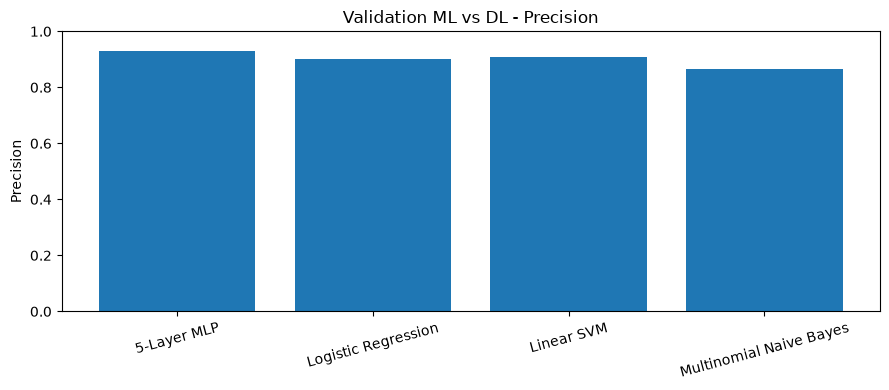

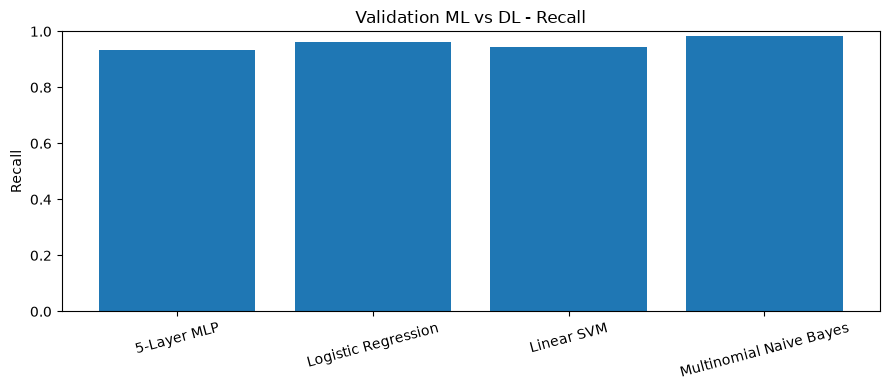

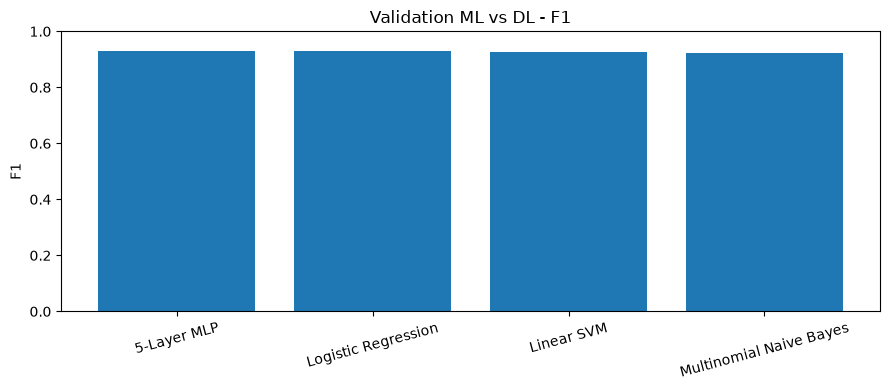

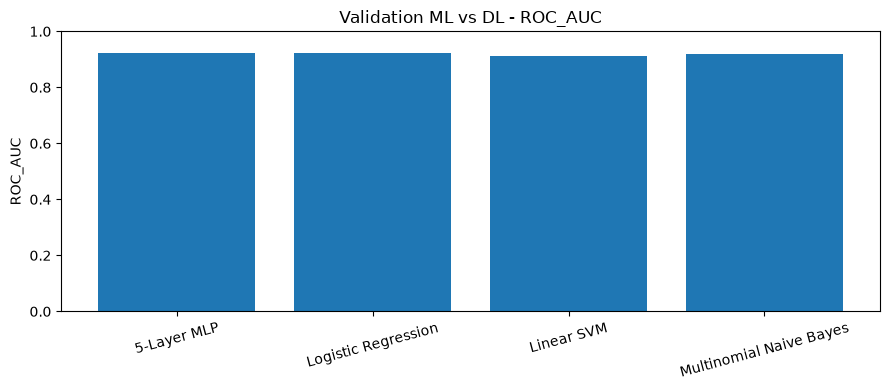

In [69]:

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]:
    plt.figure(figsize=(9, 4))
    plt.bar(
        validation_comparison["Model"],
        validation_comparison[metric]
    )
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"Validation ML vs DL - {metric}")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



# 25. Final Retraining — Train + Validation

Sau khi hyperparameters và best epoch đã được chốt:

```text
Train + Validation
       ↓
Refit TF-IDF
       ↓
Retrain 4 models
       ↓
Evaluate once on Test
```


In [70]:

X_train_val_text = pd.concat(
    [X_train_text, X_val_text],
    axis=0
)

y_train_val = pd.concat(
    [y_train, y_val],
    axis=0
)

final_vectorizer = build_vectorizer()

X_train_val_tfidf = final_vectorizer.fit_transform(
    X_train_val_text
)

X_test_final_tfidf = final_vectorizer.transform(
    X_test_text
)

final_feature_names = (
    final_vectorizer
    .get_feature_names_out()
)

print("Train + Val TF-IDF:", X_train_val_tfidf.shape)
print("Test TF-IDF       :", X_test_final_tfidf.shape)


Train + Val TF-IDF: (19244, 1500)
Test TF-IDF       : (3396, 1500)


## 25.1 Final Retrain — 3 ML Models

In [71]:

final_ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(
        random_state=RANDOM_STATE
    )
}

final_test_results = []
final_models = {}

for name, model in final_ml_models.items():

    start = time.perf_counter()

    model.fit(
        X_train_val_tfidf,
        y_train_val
    )

    training_time = time.perf_counter() - start

    test_pred = model.predict(
        X_test_final_tfidf
    )

    test_score = get_model_score(
        model,
        X_test_final_tfidf
    )

    metrics = classification_metrics(
        y_test,
        test_pred,
        test_score
    )

    final_test_results.append({
        "Model": name,
        **metrics,
        "Training Time (s)": training_time
    })

    final_models[name] = {
        "model": model,
        "prediction": test_pred,
        "score": test_score
    }


## 25.2 Final Retrain — 5-Layer MLP

In [72]:

X_train_val_dense = (
    X_train_val_tfidf
    .toarray()
    .astype(np.float32)
)

X_test_final_dense = (
    X_test_final_tfidf
    .toarray()
    .astype(np.float32)
)

X_train_val_tensor = torch.tensor(
    X_train_val_dense,
    dtype=torch.float32
)

y_train_val_tensor = torch.tensor(
    y_train_val.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

X_test_final_tensor = torch.tensor(
    X_test_final_dense,
    dtype=torch.float32
)

y_test_final_tensor = torch.tensor(
    y_test.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

final_train_loader = DataLoader(
    TensorDataset(
        X_train_val_tensor,
        y_train_val_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

final_test_loader = DataLoader(
    TensorDataset(
        X_test_final_tensor,
        y_test_final_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [73]:

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

FINAL_INPUT_DIM = X_train_val_dense.shape[1]

final_dl_model = CustomerInterestMLP(
    FINAL_INPUT_DIM
).to(device)

final_criterion = nn.BCEWithLogitsLoss()

final_optimizer = torch.optim.Adam(
    final_dl_model.parameters(),
    lr=LEARNING_RATE
)

final_dl_start = time.perf_counter()

for epoch in range(best_epoch):

    final_dl_model.train()

    for X_batch, y_batch in final_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        final_optimizer.zero_grad()

        logits = final_dl_model(
            X_batch
        )

        loss = final_criterion(
            logits,
            y_batch
        )

        loss.backward()
        final_optimizer.step()

final_dl_training_time = time.perf_counter() - final_dl_start

final_dl_test = evaluate_dl_classifier(
    final_dl_model,
    final_test_loader,
    final_criterion,
    device
)

final_test_results.append({
    "Model": "5-Layer MLP",
    "Accuracy": final_dl_test["Accuracy"],
    "Precision": final_dl_test["Precision"],
    "Recall": final_dl_test["Recall"],
    "F1": final_dl_test["F1"],
    "ROC_AUC": final_dl_test["ROC_AUC"],
    "Training Time (s)": final_dl_training_time
})

final_models["5-Layer MLP"] = {
    "model": final_dl_model,
    "prediction": final_dl_test["predictions"],
    "score": final_dl_test["probabilities"]
}


# 26. Final Test Metrics — ML vs DL

In [74]:

final_results_df = (
    pd.DataFrame(final_test_results)
    .sort_values(
        by=["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
0,Logistic Regression,0.8860,0.9019,0.9658,0.9328,0.9202,0.2933
1,5-Layer MLP,0.8855,0.9138,0.9497,0.9314,0.9156,7.0114
2,Linear SVM,0.8828,0.9099,0.9511,0.9300,0.9097,0.3354
3,Multinomial Naive Bayes,0.8634,0.8667,0.9845,0.9219,0.9115,0.0197


# 27. Final Metrics Visualization

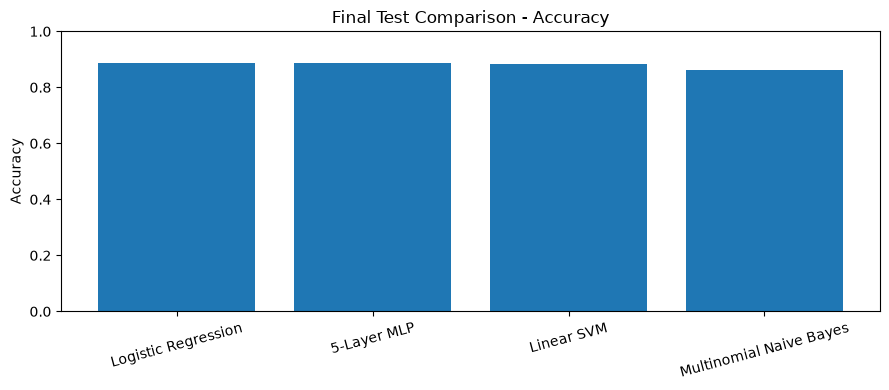

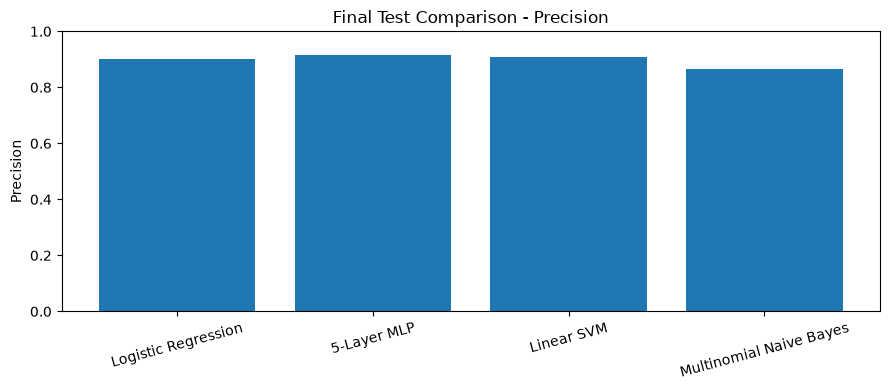

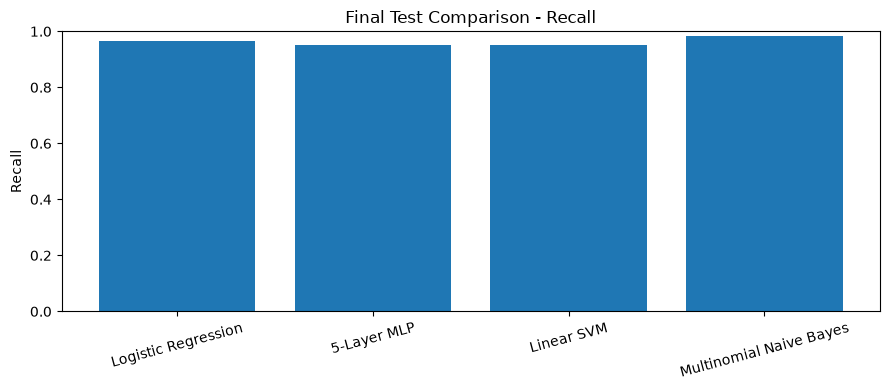

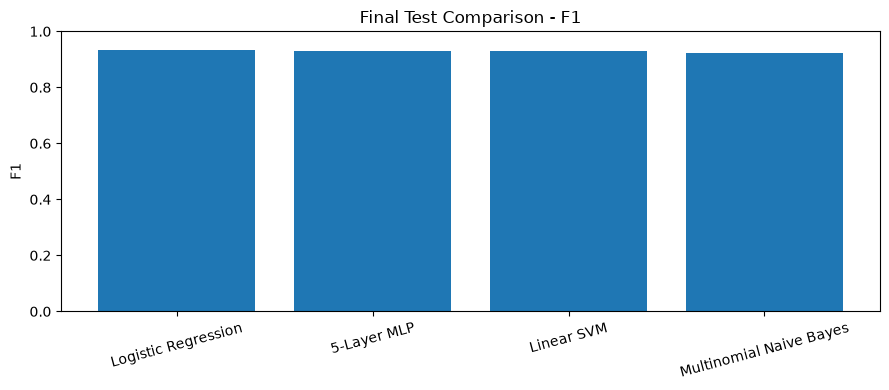

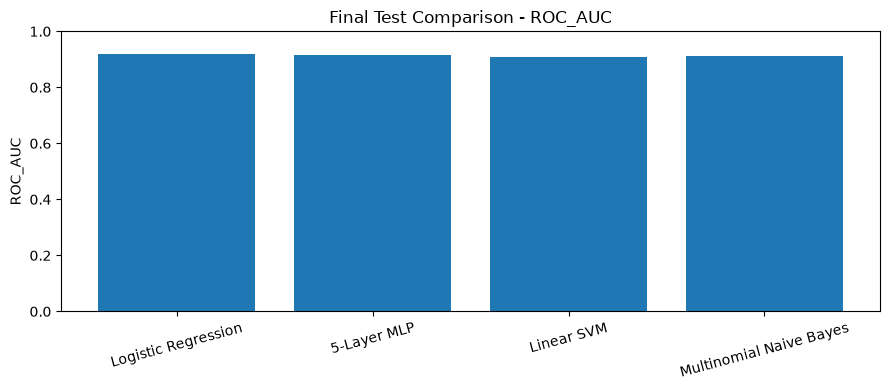

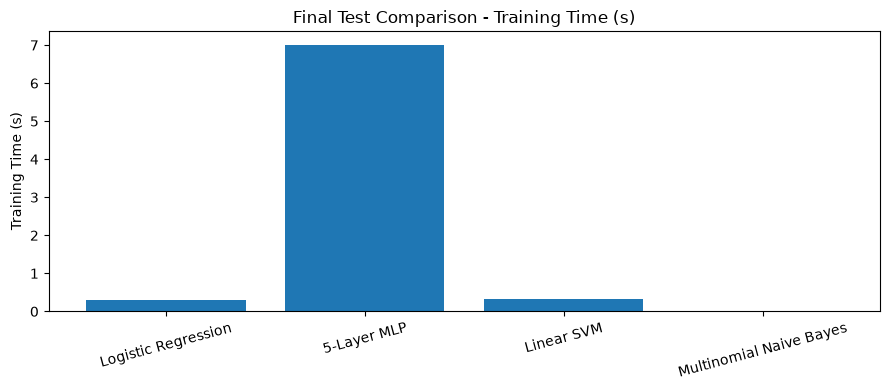

In [75]:

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "Training Time (s)"
]:
    plt.figure(figsize=(9, 4))

    plt.bar(
        final_results_df["Model"],
        final_results_df[metric]
    )

    if metric != "Training Time (s)":
        plt.ylim(0, 1)

    plt.ylabel(metric)
    plt.title(f"Final Test Comparison - {metric}")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


# 28. Classification Reports

In [76]:

for model_name, data in final_models.items():

    print("=" * 70)
    print(model_name)

    print(
        classification_report(
            y_test,
            data["prediction"],
            target_names=[
                "Not Recommended",
                "Recommended"
            ],
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
                 precision    recall  f1-score   support

Not Recommended     0.7727    0.5252    0.6254       615
    Recommended     0.9019    0.9658    0.9328      2781

       accuracy                         0.8860      3396
      macro avg     0.8373    0.7455    0.7791      3396
   weighted avg     0.8785    0.8860    0.8771      3396

Multinomial Naive Bayes
                 precision    recall  f1-score   support

Not Recommended     0.8186    0.3154    0.4554       615
    Recommended     0.8667    0.9845    0.9219      2781

       accuracy                         0.8634      3396
      macro avg     0.8426    0.6500    0.6886      3396
   weighted avg     0.8580    0.8634    0.8374      3396

Linear SVM
                 precision    recall  f1-score   support

Not Recommended     0.7219    0.5740    0.6395       615
    Recommended     0.9099    0.9511    0.9300      2781

       accuracy                         0.8828      3396
      macro avg     0.815


# 29. Confusion Matrices

\[
\begin{array}{c|cc}
 & Pred\,0 & Pred\,1\\
\hline
Actual\,0 & TN & FP\\
Actual\,1 & FN & TP
\end{array}
\]


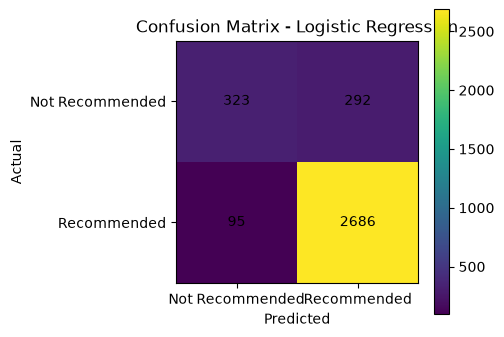

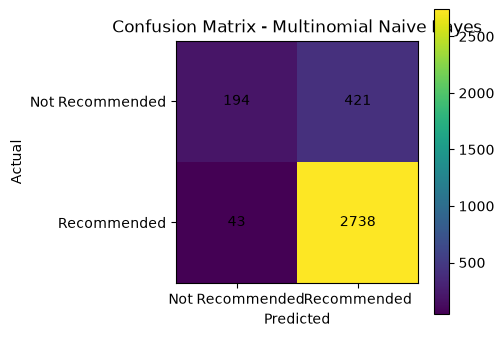

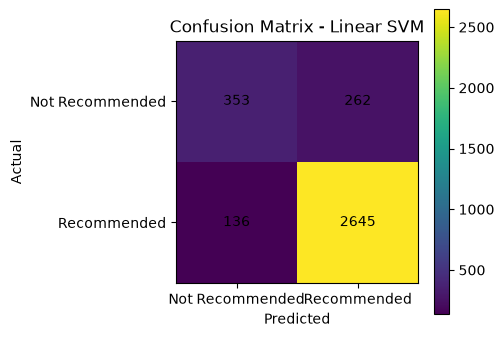

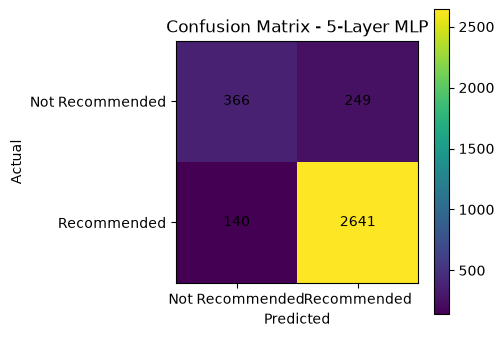

In [77]:

def plot_confusion(y_true, y_pred, model_name):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.xticks(
        [0, 1],
        ["Not Recommended", "Recommended"]
    )

    plt.yticks(
        [0, 1],
        ["Not Recommended", "Recommended"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()


for model_name, data in final_models.items():
    plot_confusion(
        y_test,
        data["prediction"],
        model_name
    )


# 30. ROC Curves

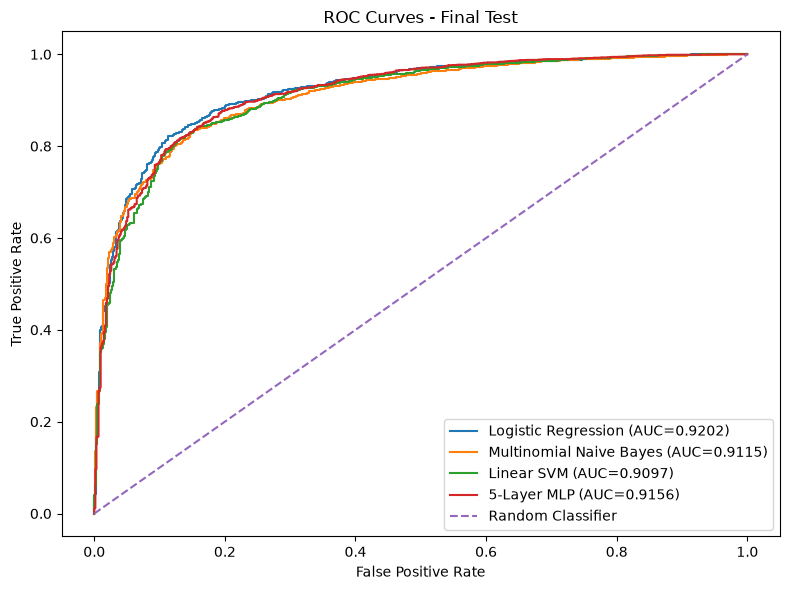

In [78]:

plt.figure(figsize=(8, 6))

for model_name, data in final_models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        data["score"]
    )

    auc = roc_auc_score(
        y_test,
        data["score"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Final Test")
plt.legend()
plt.tight_layout()
plt.show()



# 31. Text Interpretation — Logistic Regression

Coefficient lớn dương → term nghiêng về `Recommended=1`.

Coefficient âm mạnh → term nghiêng về `Not Recommended=0`.


Terms associated with RECOMMENDED:


,Term,Coefficient
758,love,5.507825
922,perfect,4.608252
712,little,3.762955
242,comfortable,3.717426
251,compliments,3.576170
536,great,3.476741
467,fits,3.329759
1371,unique,3.272355
1202,soft,3.010791
129,bit,2.816028



Terms associated with NOT RECOMMENDED:


,Term,Coefficient
325,disappointed,-5.274081
1409,wanted love,-5.137783
1047,returned,-4.001291
202,cheap,-3.747040
1048,returning,-3.712849
1369,unflattering,-3.705427
601,huge,-3.285529
95,awful,-3.228730
404,excited,-3.142678
970,poor,-3.045688


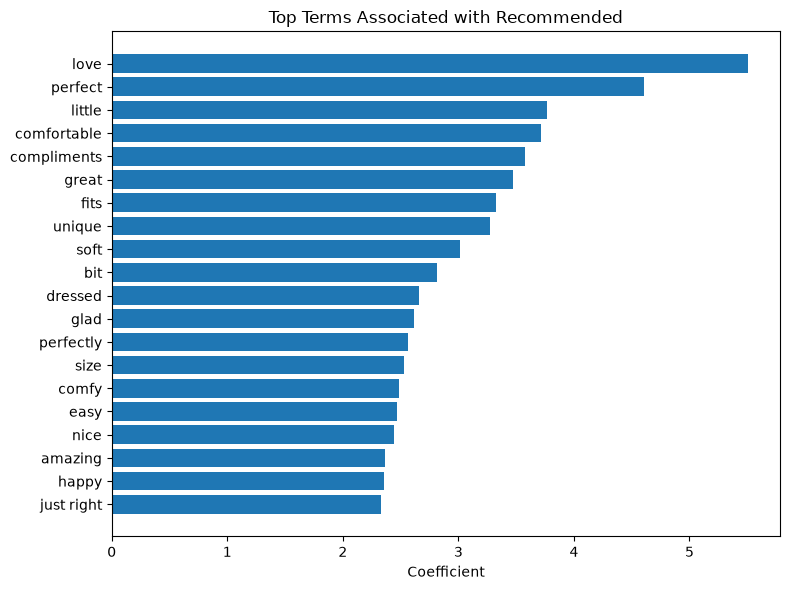

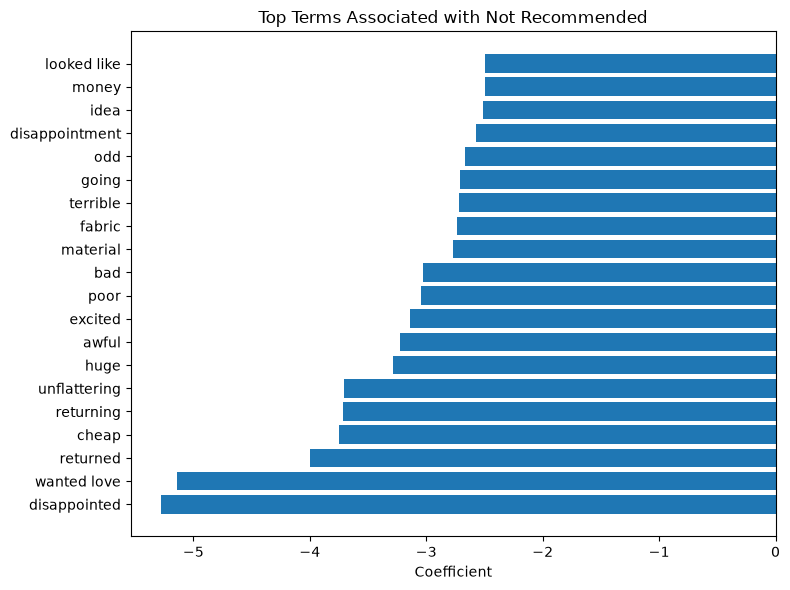

In [79]:

final_logistic = final_models[
    "Logistic Regression"
]["model"]

coefficients = final_logistic.coef_[0]

term_coefficients = pd.DataFrame({
    "Term": final_feature_names,
    "Coefficient": coefficients
})

top_positive_terms = (
    term_coefficients
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(20)
)

top_negative_terms = (
    term_coefficients
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .head(20)
)

print("Terms associated with RECOMMENDED:")
display(top_positive_terms)

print("\nTerms associated with NOT RECOMMENDED:")
display(top_negative_terms)

plt.figure(figsize=(8, 6))
plt.barh(
    top_positive_terms["Term"][::-1],
    top_positive_terms["Coefficient"][::-1]
)
plt.xlabel("Coefficient")
plt.title("Top Terms Associated with Recommended")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(
    top_negative_terms["Term"],
    top_negative_terms["Coefficient"]
)
plt.xlabel("Coefficient")
plt.title("Top Terms Associated with Not Recommended")
plt.tight_layout()
plt.show()



# 32. Learned Representation Analysis

Assignment 03 hỏi:

> What does a neural network actually learn?

Ta lấy output Layer 4:

\[
H_4 \in \mathbb{R}^{N\times32}
\]

Flow:

\[
x
\rightarrow h_1
\rightarrow h_2
\rightarrow h_3
\rightarrow h_4
\rightarrow \hat y
\]

PCA chỉ được dùng để visualize \(H_4\) xuống 2 chiều.


In [80]:

def extract_h4(model, X_tensor, device):

    model.eval()

    with torch.no_grad():

        x = X_tensor.to(device)

        h1 = model.relu(
            model.fc1(x)
        )

        h2 = model.relu(
            model.fc2(h1)
        )

        h3 = model.relu(
            model.fc3(h2)
        )

        h4 = model.relu(
            model.fc4(h3)
        )

    return h4.cpu().numpy()


h4_test = extract_h4(
    final_dl_model,
    X_test_final_tensor,
    device
)

print("Original TF-IDF test shape:", X_test_final_tensor.shape)
print("Learned H4 shape          :", h4_test.shape)


Original TF-IDF test shape: torch.Size([3396, 1500])
Learned H4 shape          : (3396, 32)


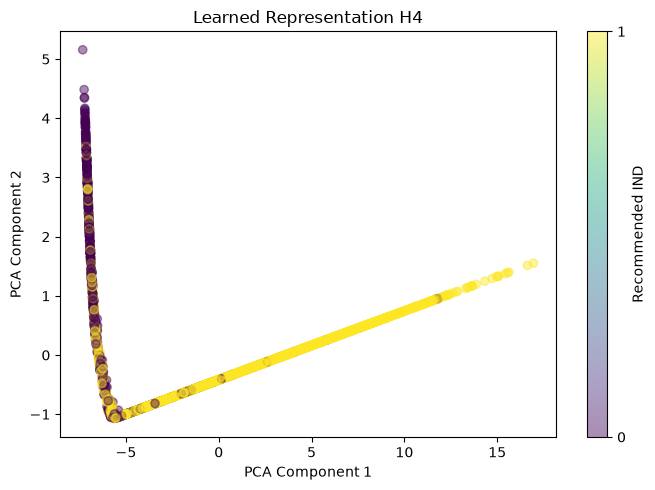

In [81]:

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

h4_2d = pca.fit_transform(
    h4_test
)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    h4_2d[:, 0],
    h4_2d[:, 1],
    c=y_test.to_numpy(),
    alpha=0.45
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Learned Representation H4")

plt.colorbar(
    scatter,
    ticks=[0, 1],
    label="Recommended IND"
)

plt.tight_layout()
plt.show()



# 33. Scientific ML vs DL Comparison

Không chỉ hỏi model nào có Accuracy cao hơn.

| Criterion | Logistic Regression | Naive Bayes | Linear SVM | 5-Layer MLP |
|---|---|---|---|---|
| Prepared input | TF-IDF | TF-IDF | TF-IDF | TF-IDF |
| Hidden learned representation | No | No | No | **Yes** |
| Nonlinearity | Limited | Probabilistic | Linear boundary | **Multiple ReLU layers** |
| Interpretability | Higher | Medium | Medium | Lower |
| Training cost | Low | Very low | Low/Medium | Higher |
| Learning | Coefficients | Probabilities | Hyperplane | Backprop + Adam |

## Discussion Questions

1. Model nào có F1 cao nhất?
2. Model nào có ROC-AUC cao nhất?
3. Accuracy có đủ khi class bị lệch không?
4. DL có cải thiện Recall/F1 không?
5. Improvement có xứng đáng với training cost không?
6. Train/Validation curves có overfitting không?
7. Learned space \(H_4\) có structure rõ hơn không?
8. Traditional ML hay DL dễ giải thích hơn?



# 34. Business / Behavioral Interpretation

Prediction:

```text
User Review
   ↓
Model
   ↓
Recommended / Not Recommended
```

Ứng dụng:

- phân tích phản hồi khách hàng;
- xác định review có positive recommendation intention;
- hỗ trợ product feedback analysis;
- hỗ trợ CRM / marketing / recommendation analysis.

Giới hạn diễn giải:

> Model dự đoán `Recommended IND` từ review text. Nó không trực tiếp đo customer lifetime value hay toàn bộ purchase behavior.



# 35. Conclusion Template

> The Women's E-Commerce Clothing Reviews dataset was used to model customer recommendation interest from review text. Three traditional machine-learning models—Logistic Regression, Multinomial Naive Bayes, and Linear SVM—were compared with a five-layer MLP. Review text was converted to a TF-IDF numerical representation, while the deep network further transformed this representation through four hidden layers before producing the final binary prediction. All models were evaluated on the same held-out test set using Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrices, and training time. The best-performing model was ______ according to ______. The five-layer MLP achieved ______, but its performance improvement should be considered together with its larger parameter count, training cost, and lower interpretability.


# 36. Save Artifacts

In [82]:

OUTPUT_DIR = Path(
    "customer_behavior_assignment3_artifacts"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_vectorizer,
    OUTPUT_DIR / "tfidf_vectorizer.joblib"
)

for name in [
    "Logistic Regression",
    "Multinomial Naive Bayes",
    "Linear SVM"
]:
    safe_name = (
        name.lower()
        .replace(" ", "_")
    )

    joblib.dump(
        final_models[name]["model"],
        OUTPUT_DIR / f"{safe_name}.joblib"
    )

torch.save(
    {
        "model_state_dict": final_dl_model.state_dict(),
        "input_dim": FINAL_INPUT_DIM,
        "architecture": [
            FINAL_INPUT_DIM,
            256,
            128,
            64,
            32,
            1
        ],
        "learning_rate": LEARNING_RATE,
        "epochs": best_epoch,
        "max_tfidf_features": MAX_FEATURES
    },
    OUTPUT_DIR / "customer_interest_5_layer_mlp.pth"
)

metadata = {
    "dataset": "Women's E-Commerce Clothing Reviews",
    "input": TEXT_COLUMN,
    "target": TARGET,
    "target_definition": {
        0: "Not Recommended",
        1: "Recommended"
    },
    "max_tfidf_features": MAX_FEATURES,
    "vocabulary_size": len(final_feature_names),
    "best_dl_epoch": best_epoch,
    "dl_parameter_count": sum(
        p.numel()
        for p in final_dl_model.parameters()
        if p.requires_grad
    )
}

joblib.dump(
    metadata,
    OUTPUT_DIR / "metadata.joblib"
)

final_results_df.to_csv(
    OUTPUT_DIR / "customer_behavior_model_comparison.csv",
    index=False
)

print("Saved artifacts:")

for path in OUTPUT_DIR.iterdir():
    print("-", path.name)


Saved artifacts:
- customer_behavior_model_comparison.csv
- customer_interest_5_layer_mlp.pth
- linear_svm.joblib
- logistic_regression.joblib
- metadata.joblib
- multinomial_naive_bayes.joblib
- tfidf_vectorizer.joblib



# 37. Final Report Checklist

Nên chụp / đưa vào Technical Report:

1. Dataset shape + columns
2. Missing values
3. Class distribution
4. Review length distribution
5. Rating distribution / Recommended rate by Rating
6. Raw Review → TF-IDF representation
7. TF-IDF matrix shape
8. 3 ML validation comparison
9. \(z=w^Tx+b\)
10. ReLU formula
11. 5-layer forward formulas
12. BCE formula
13. Gradient descent / Training Cycle
14. MLP architecture + tensor shapes
15. Trainable parameter count
16. Training vs Validation Loss
17. Training vs Validation Accuracy
18. Training vs Validation F1
19. Final ML vs DL metrics
20. Confusion matrices
21. ROC curves
22. Important TF-IDF terms
23. Learned Representation H4 + PCA
24. Training-time comparison
25. Performance vs Complexity vs Interpretability discussion



# Appendix — Functions You Must Be Able to Explain

| Code | Meaning |
|---|---|
| `TfidfVectorizer()` | Convert text to prepared numerical representation |
| `fit_transform(train)` | Learn vocabulary/IDF from Train and transform Train |
| `transform(val/test)` | Use learned representation without leakage |
| `nn.Module` | Base class for neural network |
| `nn.Linear(a,b)` | Linear transformation |
| `nn.ReLU()` | Nonlinear activation |
| `forward()` | Forward propagation |
| `TensorDataset` | Pair X/y tensors |
| `DataLoader` | Mini-batch iterator |
| `model.train()` | Training mode |
| `model.eval()` | Evaluation mode |
| `optimizer.zero_grad()` | Reset old gradients |
| `loss.backward()` | Backpropagation |
| `optimizer.step()` | Update parameters |
| `torch.no_grad()` | Disable gradient during evaluation |
| `torch.sigmoid()` | Logit → probability |
| `state_dict()` | Learned PyTorch parameter state |
